<a href="https://colab.research.google.com/github/sharvani1357/LLMs/blob/main/MINI_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("bbc-text.csv")
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nShape:")
print(df.shape)

        category                                               text
0           tech  tv future in the hands of viewers with home th...
1       business  worldcom boss  left books alone  former worldc...
2          sport  tigers wary of farrell  gamble  leicester say ...
3          sport  yeading face newcastle in fa cup premiership s...
4  entertainment  ocean s twelve raids box office ocean s twelve...

Columns:
Index(['category', 'text'], dtype='object')

Shape:
(1838, 2)


In [2]:


import pandas as pd
import re

df = pd.read_csv("bbc-text.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)


articles = df["text"]


# HANDLE MISSING VALUES
df = df.dropna(subset=["text"])
print("\nAfter Removing Missing Values:")
print(df.shape)


# TEXT CLEANING FUNCTION
def clean_text(text):
# lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r"[^a-zA-Z\s]","",text)

    # remove extra spaces
    text = re.sub(r"\s+"," ",text)
    text = text.strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)

# DISPLAY SAMPLE RECORDS
print("\nSample Cleaned Articles:\n")

for i in range(3):
    print("=" * 80)
    print("Category:",df.iloc[i]["category"])
    print("\nOriginal Text:\n")
    print(df.iloc[i]["text"][:300])
    print("\nCleaned Text:\n")
    print(df.iloc[i]["clean_text"][:300])

    print()

Dataset Shape:
(2225, 2)

Columns:
Index(['category', 'text'], dtype='object')

After Removing Missing Values:
(2225, 2)

Sample Cleaned Articles:

Category: tech

Original Text:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer elect

Cleaned Text:

tv future in the hands of viewers with home theatre systems plasma highdefinition tvs and digital video recorders moving into the living room the way people watch tv will be radically different in five years time that is according to an expert panel which gathered at the annual consumer electronics 

Category: business

Original Text:

worldcom boss  left books alone  former worldcom boss bernie ebbers  who is accused of overseeing an $11bn (£5.8bn) fraud  never made accounting decisions  a witness

In [3]:
# ==========================================
# TASK 2 : CREATE VOCABULARY
# ==========================================

from collections import Counter

# ------------------------------------------
# GET CLEANED TEXTS
# ------------------------------------------

texts = df["clean_text"].tolist()

# ------------------------------------------
# COLLECT ALL WORDS
# ------------------------------------------

all_words = []

for text in texts:

    words = text.split()

    all_words.extend(words)

# ------------------------------------------
# WORD FREQUENCY
# ------------------------------------------

word_counts = Counter(all_words)

# ------------------------------------------
# VOCABULARY SIZE
# ------------------------------------------

vocab_size = 10000

most_common_words = word_counts.most_common(
    vocab_size - 2
)

# ------------------------------------------
# SPECIAL TOKENS
# ------------------------------------------

vocab = [
    "<PAD>",
    "<UNK>"
]

for word, _ in most_common_words:

    vocab.append(word)

# ------------------------------------------
# WORD -> ID
# ------------------------------------------

word2idx = {

    word: idx

    for idx, word
    in enumerate(vocab)

}

# ------------------------------------------
# ID -> WORD
# ------------------------------------------

idx2word = {

    idx: word

    for word, idx
    in word2idx.items()

}

print("Vocabulary Size:")
print(len(vocab))

print("\nFirst 20 Words:")
print(vocab[:20])

Vocabulary Size:
10000

First 20 Words:
['<PAD>', '<UNK>', 'the', 'to', 'of', 'and', 'a', 'in', 's', 'for', 'is', 'that', 'it', 'on', 'said', 'was', 'he', 'be', 'with', 'as']


In [4]:
# ==========================================
# TASK 3 : TOKENIZATION
# ==========================================

tokenized_texts = []

for text in texts:

    tokens = text.split()

    encoded = [

        word2idx.get(
            word,
            word2idx["<UNK>"]
        )

        for word in tokens

    ]

    tokenized_texts.append(
        encoded
    )

print("Sample Encoded Article:\n")

print(
    tokenized_texts[0][:50]
)

print(
    "\nDecoded Back:\n"
)

decoded = [

    idx2word[idx]

    for idx in tokenized_texts[0][:30]

]

print(decoded)

Sample Encoded Article:

[178, 241, 7, 2, 1252, 4, 1234, 18, 126, 1146, 793, 5087, 1284, 4156, 5, 216, 260, 4016, 1429, 77, 2, 1353, 1667, 2, 117, 46, 979, 178, 24, 17, 6379, 401, 7, 185, 81, 73, 11, 10, 211, 3, 35, 3036, 1368, 36, 2464, 22, 2, 639, 493, 1299]

Decoded Back:

['tv', 'future', 'in', 'the', 'hands', 'of', 'viewers', 'with', 'home', 'theatre', 'systems', 'plasma', 'highdefinition', 'tvs', 'and', 'digital', 'video', 'recorders', 'moving', 'into', 'the', 'living', 'room', 'the', 'way', 'people', 'watch', 'tv', 'will', 'be']


In [5]:
# ==========================================
# TASK 4 : EMBEDDINGS
# ==========================================

import torch
import torch.nn as nn

embedding_dim = 128

embedding_layer = nn.Embedding(
    len(vocab),
    embedding_dim
)

sample_ids = torch.tensor(
    tokenized_texts[0][:20],
    dtype=torch.long
)

token_embeddings = embedding_layer(
    sample_ids
)

print(
    "Embedding Shape:"
)

print(
    token_embeddings.shape
)

Embedding Shape:
torch.Size([20, 128])


In [6]:
# ==========================================
# TASK 5 : POSITIONAL ENCODING
# ==========================================

max_seq_len = 100

position_embedding_layer = nn.Embedding(
    max_seq_len,
    embedding_dim
)

seq_len = len(sample_ids)

position_ids = torch.arange(
    seq_len
)

position_embeddings = \
position_embedding_layer(
    position_ids
)

transformer_input = (
    token_embeddings
    +
    position_embeddings
)

print(
    transformer_input.shape
)

torch.Size([20, 128])


In [7]:
# ==========================================
# TASK 6 : MASKED MULTIHEAD ATTENTION
# ==========================================

import torch.nn.functional as F
import math

num_heads = 4

mha = nn.MultiheadAttention(
    embed_dim=128,
    num_heads=num_heads,
    batch_first=True
)

batch_input = \
transformer_input.unsqueeze(0)

seq_len = batch_input.size(1)

mask = torch.triu(
    torch.ones(
        seq_len,
        seq_len
    ),
    diagonal=1
).bool()

attention_output, attention_weights = \
    mha(
        batch_input,
        batch_input,
        batch_input,
        attn_mask=mask
    )

print(
    "Attention Output Shape:"
)

print(
    attention_output.shape
)

Attention Output Shape:
torch.Size([1, 20, 128])


In [21]:
# ==========================================
# TASK 7 : GPT DECODER BLOCK
# ==========================================

import torch
import torch.nn as nn

class FeedForwardNetwork(nn.Module):

    def __init__(
            self,
            embed_dim=128,
            ff_dim=512):

        super().__init__()

        self.fc1 = nn.Linear(
            embed_dim,
            ff_dim
        )

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(
            ff_dim,
            embed_dim
        )

    def forward(self, x):

        return self.fc2(
            self.relu(
                self.fc1(x)
            )
        )


class GPTDecoderBlock(nn.Module):

    def __init__(
            self,
            embed_dim=128,
            num_heads=4,
            ff_dim=512,
            dropout=0.1):

        super().__init__()

        self.mha = nn.MultiheadAttention(
            embed_dim,
            num_heads,
            batch_first=True
        )

        self.dropout1 = nn.Dropout(
            dropout
        )

        self.norm1 = nn.LayerNorm(
            embed_dim
        )

        self.ffn = FeedForwardNetwork(
            embed_dim,
            ff_dim
        )

        self.dropout2 = nn.Dropout(
            dropout
        )

        self.norm2 = nn.LayerNorm(
            embed_dim
        )

    def forward(self, x):

        seq_len = x.size(1)

        mask = torch.triu(
            torch.ones(
                seq_len,
                seq_len
            ),
            diagonal=1
        ).bool().to(
            x.device
        )

        attention_output, _ = self.mha(
            x,
            x,
            x,
            attn_mask=mask
        )

        attention_output = \
            self.dropout1(
                attention_output
            )

        x = self.norm1(
            x + attention_output
        )

        ffn_output = self.ffn(x)

        ffn_output = \
            self.dropout2(
                ffn_output
            )

        x = self.norm2(
            x + ffn_output
        )

        return x

In [9]:
# ==========================================
# TASK 8 : STACK DECODERS
# ==========================================

decoder1 = GPTDecoderBlock()

decoder2 = GPTDecoderBlock()

x = transformer_input.unsqueeze(0)

x = decoder1(x)

x = decoder2(x)

print(
    "Stacked Decoder Output:"
)

print(
    x.shape
)

Stacked Decoder Output:
torch.Size([1, 20, 128])


In [10]:
print(len(vocab))
print(len(tokenized_texts))

10000
2225


Epoch 1/5 Loss: 4.9119
Epoch 2/5 Loss: 3.9234
Epoch 3/5 Loss: 3.0110
Epoch 4/5 Loss: 2.1334
Epoch 5/5 Loss: 1.4005

Training Completed!


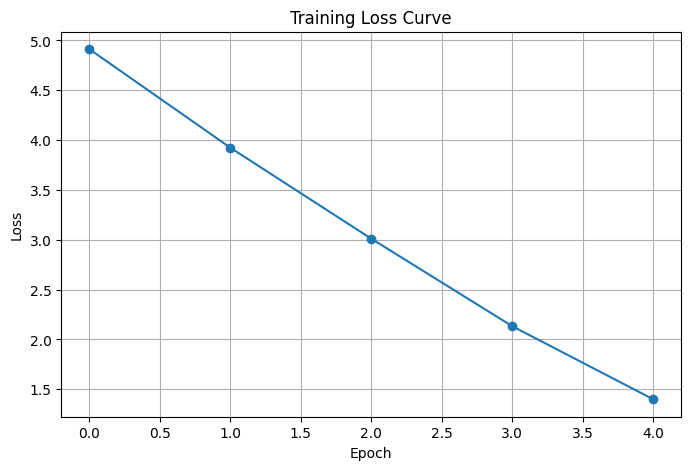

In [22]:
# ==========================================
# TASK 9 : TRAIN MODEL
# ==========================================

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ------------------------------------------
# SMALL SUBSET
# ------------------------------------------

X_small = X[:20000]
Y_small = Y[:20000]

dataset = TensorDataset(
    X_small,
    Y_small
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

# ------------------------------------------
# DEVICE
# ------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 5

loss_history = []

# ------------------------------------------
# TRAINING
# ------------------------------------------

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch_X, batch_Y in loader:

        batch_X = batch_X.to(device)

        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(
            batch_X
        )

        logits = outputs[:, -1, :]

        loss = criterion(
            logits,
            batch_Y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = (
        total_loss / len(loader)
    )

    loss_history.append(
        avg_loss
    )

    print(
        f"Epoch {epoch+1}/{epochs}"
        f" Loss: {avg_loss:.4f}"
    )

print(
    "\nTraining Completed!"
)

# ------------------------------------------
# LOSS GRAPH
# ------------------------------------------

plt.figure(
    figsize=(8,5)
)

plt.plot(
    loss_history,
    marker="o"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training Loss Curve"
)

plt.grid(True)

plt.show()

In [23]:
# ==========================================
# TASK 10 : TEXT GENERATION
# ==========================================

import torch

def generate_text(
        prompt,
        max_new_tokens=20):

    model.eval()

    words = prompt.lower().split()

    for _ in range(max_new_tokens):

        token_ids = [

            word2idx.get(
                word,
                word2idx["<UNK>"]
            )

            for word in words

        ]

        token_ids = token_ids[-30:]

        padding = [0] * (
            30 - len(token_ids)
        )

        token_ids = (
            padding + token_ids
        )

        input_tensor = torch.tensor(
            [token_ids],
            dtype=torch.long
        ).to(device)

        with torch.no_grad():

            outputs = model(
                input_tensor
            )

        logits = outputs[:, -1, :]

        next_token = torch.argmax(
            logits,
            dim=-1
        ).item()

        next_word = idx2word.get(
            next_token,
            "<UNK>"
        )

        words.append(
            next_word
        )

    return " ".join(
        words
    )

In [24]:
prompts = [

    "machine learning",

    "artificial intelligence",

    "global economy",

    "football team",

    "prime minister"

]

for prompt in prompts:

    print("="*80)

    print(
        "INPUT:",
        prompt
    )

    print()

    print(
        "GENERATED:"
    )

    print(
        generate_text(
            prompt
        )
    )

    print()

INPUT: machine learning

GENERATED:
machine learning bates seals takeover of homes in the final salary has now admitted one of the s four scotland s important

INPUT: artificial intelligence

GENERATED:
artificial intelligence ham future the third ferguson was denied s four domecq with a dinner the club will be a series of

INPUT: global economy

GENERATED:
global economy back on japan s twelve the us crude oil closed up to name of the us insurance m workers the

INPUT: football team

GENERATED:
football team are getting of farrell gamble leicester say they can t are good an operation of the government shouldn at the

INPUT: prime minister

GENERATED:
prime minister hopes the future has been released to be a bid from a bid is likely to move will be from



In [25]:
def generate_topk(
        prompt,
        k=10,
        max_new_tokens=20):

    model.eval()

    words = prompt.lower().split()

    for _ in range(max_new_tokens):

        token_ids = [

            word2idx.get(
                word,
                word2idx["<UNK>"]
            )

            for word in words

        ]

        token_ids = token_ids[-30:]

        padding = [0]*(30-len(token_ids))

        token_ids = padding + token_ids

        input_tensor = torch.tensor(
            [token_ids]
        ).to(device)

        with torch.no_grad():

            outputs = model(
                input_tensor
            )

        logits = outputs[:, -1, :]

        topk_logits, topk_indices = \
            torch.topk(
                logits,
                k
            )

        probs = torch.softmax(
            topk_logits,
            dim=-1
        )

        selected = torch.multinomial(
            probs,
            1
        )

        next_token = \
            topk_indices[0][selected]

        next_word = idx2word.get(
            next_token.item(),
            "<UNK>"
        )

        words.append(
            next_word
        )

    return " ".join(words)

In [26]:
def generate_temperature(
        prompt,
        temperature=0.7,
        max_new_tokens=20):

    model.eval()

    words = prompt.lower().split()

    for _ in range(max_new_tokens):

        token_ids = [

            word2idx.get(
                word,
                word2idx["<UNK>"]
            )

            for word in words

        ]

        token_ids = token_ids[-30:]

        padding = [0]*(30-len(token_ids))

        token_ids = padding + token_ids

        input_tensor = torch.tensor(
            [token_ids]
        ).to(device)

        with torch.no_grad():

            outputs = model(
                input_tensor
            )

        logits = outputs[:, -1, :]

        logits = logits / temperature

        probs = torch.softmax(
            logits,
            dim=-1
        )

        next_token = torch.multinomial(
            probs,
            1
        ).item()

        next_word = idx2word.get(
            next_token,
            "<UNK>"
        )

        words.append(
            next_word
        )

    return " ".join(words)

In [27]:
prompt = "artificial intelligence"

print("GREEDY SEARCH\n")

print(
    generate_text(prompt)
)

print("\n")

print("TOP-K SAMPLING\n")

print(
    generate_topk(
        prompt,
        k=10
    )
)

GREEDY SEARCH

artificial intelligence ham future the third ferguson was denied s four domecq with a dinner the club will be a series of


TOP-K SAMPLING

artificial intelligence eyes two psp has bought almost <UNK> two by the company known for ferguson south korea s achieved <UNK> two


In [28]:
import math

model.eval()

total_loss = 0

with torch.no_grad():

    for batch_X, batch_Y in loader:

        batch_X = batch_X.to(device)

        batch_Y = batch_Y.to(device)

        outputs = model(
            batch_X
        )

        logits = outputs[:, -1, :]

        loss = criterion(
            logits,
            batch_Y
        )

        total_loss += loss.item()

avg_loss = total_loss / len(loader)

perplexity = math.exp(
    avg_loss
)

print(
    "Loss:",
    round(avg_loss,4)
)

print(
    "Perplexity:",
    round(perplexity,4)
)

Loss: 0.689
Perplexity: 1.9916


In [30]:
import torch
import pickle
import os

os.makedirs(
    "saved_model",
    exist_ok=True
)

torch.save(
    model.state_dict(),
    "saved_model/mini_gpt.pth"
)

with open(
        "saved_model/word2idx.pkl",
        "wb") as f:
    pickle.dump(
        word2idx,
        f
    )

with open(
        "saved_model/idx2word.pkl",
        "wb") as f:
    pickle.dump(
        idx2word,
        f
    )

print("Files Saved Successfully")

Files Saved Successfully


In [31]:
from google.colab import files

files.download(
    "saved_model/mini_gpt.pth"
)

files.download(
    "saved_model/word2idx.pkl"
)

files.download(
    "saved_model/idx2word.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>